# ML Assignment 1

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import make_scorer

# Paths to your files (update these!)
TRAIN_PATH = "https://drive.google.com/uc?export=download&id=18kpPgnoDfOfx3PRRZY3xbsLeWalNViYl"
TEST_PATH  = "https://drive.google.com/uc?export=download&id=1HJlgPTkGlCzycSTnJNB0oJEfgjSV4o0f"
SAMPLE_SUB_PATH = "https://drive.google.com/file/d/1g_hQQtI80Dz0NkGXG8ZioND9iVGTerd8/view?usp=drive_link"

# RMSLE function
def rmsle(y_true, y_pred):
    # Ensure predictions are non-negative before logging
    y_pred = np.maximum(0, y_pred)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2))

rmsle_scorer = make_scorer(rmsle, greater_is_better=False)

# Load data
train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

train.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2012-07-15 7:00:00,3,0,0,1,28.70000,33.335000,79,6.003200,17,30,47
1,2012-08-14 15:00:00,3,0,1,1,33.62000,37.880000,46,15.001300,84,199,283
2,2011-02-06 6:00:00,1,0,0,1,10.66000,12.880000,60,15.001300,0,1,1
3,2012-05-06 17:00:02,2,0,0,2,26.42506,30.566166,61,9.512288,198,330,531
4,2012-01-09 2:00:00,1,0,1,1,9.84000,12.120000,56,8.998100,2,3,5


In [19]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.info()
print(train.isnull().sum())


Train shape: (10450, 12)
Test shape: (2613, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10450 entries, 0 to 10449
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10450 non-null  object 
 1   season      10450 non-null  int64  
 2   holiday     10450 non-null  int64  
 3   workingday  10450 non-null  int64  
 4   weather     10450 non-null  int64  
 5   temp        10450 non-null  float64
 6   atemp       10450 non-null  float64
 7   humidity    10450 non-null  int64  
 8   windspeed   10450 non-null  float64
 9   casual      10450 non-null  int64  
 10  registered  10450 non-null  int64  
 11  count       10450 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 979.8+ KB
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64


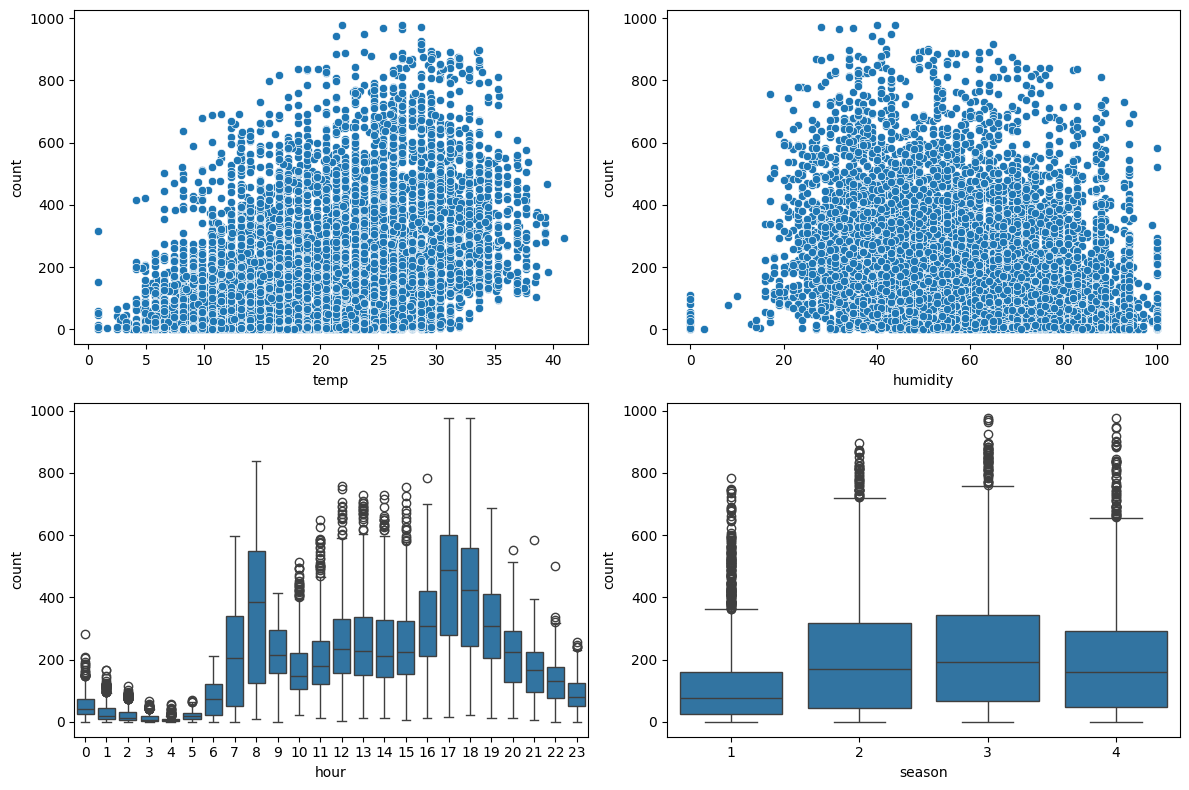

In [20]:
train['datetime'] = pd.to_datetime(train['datetime'])
train['hour'] = train['datetime'].dt.hour
train['weekday'] = train['datetime'].dt.weekday
train['month'] = train['datetime'].dt.month

fig, axes = plt.subplots(2, 2, figsize=(12,8))
sns.scatterplot(x='temp', y='count', data=train, ax=axes[0,0])
sns.scatterplot(x='humidity', y='count', data=train, ax=axes[0,1])
sns.boxplot(x='hour', y='count', data=train, ax=axes[1,0])
sns.boxplot(x='season', y='count', data=train, ax=axes[1,1])
plt.tight_layout()
plt.show()


In [21]:
corr = train.corr()['count'].sort_values(ascending=False)
print(corr)


count         1.000000
registered    0.970108
casual        0.691971
hour          0.404188
temp          0.396451
atemp         0.390642
datetime      0.307060
month         0.165475
season        0.160333
windspeed     0.105318
workingday    0.017361
holiday      -0.005615
weekday      -0.006489
weather      -0.124402
humidity     -0.316607
Name: count, dtype: float64


In [22]:
def add_time_features(df):
    df = df.copy()
    df['datetime'] = pd.to_datetime(df['datetime'], dayfirst=True)
    df['hour'] = df['datetime'].dt.hour
    df['weekday'] = df['datetime'].dt.weekday
    df['month'] = df['datetime'].dt.month
    df['year'] = df['datetime'].dt.year
    return df

train_fe = add_time_features(train)
test_fe  = add_time_features(test)

# Drop 'casual' and 'registered' from features as they are not available in test data
X = train_fe.drop(columns=['count','datetime', 'casual', 'registered'])
y = train_fe['count']

numeric_features = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

In [23]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

preprocess = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

linreg_pipe = Pipeline([
    ('preprocess', preprocess),
    ('model', LinearRegression())
])

linreg_pipe.fit(X_train, y_train)
y_val_pred_lr = np.maximum(linreg_pipe.predict(X_val), 0)
print("Linear Regression RMSLE:", rmsle(y_val, y_val_pred_lr))


Linear Regression RMSLE: 1.4215380136667097


In [24]:
poly_num = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

preprocess_poly = ColumnTransformer([
    ('num', poly_num, numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

# Ridge
ridge_pipe = Pipeline([
    ('preprocess', preprocess_poly),
    ('model', Ridge())
])
ridge_grid = GridSearchCV(ridge_pipe, {'model__alpha':[0.1,1,10]}, scoring=rmsle_scorer, cv=3)
ridge_grid.fit(X_train, y_train)
y_val_pred_ridge = np.maximum(ridge_grid.predict(X_val), 0)
print("Ridge RMSLE:", rmsle(y_val, y_val_pred_ridge))

# Lasso
lasso_pipe = Pipeline([
    ('preprocess', preprocess_poly),
    ('model', Lasso(max_iter=10000))
])
lasso_grid = GridSearchCV(lasso_pipe, {'model__alpha':[0.001,0.01,0.1]}, scoring=rmsle_scorer, cv=3)
lasso_grid.fit(X_train, y_train)
y_val_pred_lasso = np.maximum(lasso_grid.predict(X_val), 0)
print("Lasso RMSLE:", rmsle(y_val, y_val_pred_lasso))


Ridge RMSLE: 1.342120869048516


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.584e+07, tolerance: 1.798e+04
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.094e+07, tolerance: 1.818e+04
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.985e+07, tolerance: 1.862e

Lasso RMSLE: 1.3462551121364226


In [25]:
results = pd.DataFrame({
    'Model': ['Linear Regression','Ridge','Lasso'],
    'RMSLE': [rmsle(y_val,y_val_pred_lr), rmsle(y_val,y_val_pred_ridge), rmsle(y_val,y_val_pred_lasso)]
})
print(results)


               Model     RMSLE
0  Linear Regression  1.421538
1              Ridge  1.342121
2              Lasso  1.346255


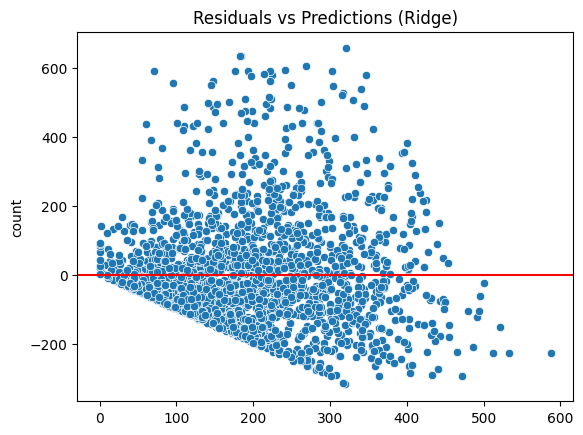

In [26]:
residuals = y_val - y_val_pred_ridge
sns.scatterplot(x=y_val_pred_ridge, y=residuals)
plt.axhline(0, color='red')
plt.title("Residuals vs Predictions (Ridge)")
plt.show()


In [28]:
# Final training on full data
X_full = train_fe.drop(columns=['count','datetime'])
y_full = train_fe['count']

final_model = ridge_grid.best_estimator_   # or whichever model was best
final_model.fit(X_full, y_full)

# Predict on test
X_test_final = test_fe.drop(columns=['datetime'])
test_pred = np.maximum(final_model.predict(X_test_final), 0)

# Build submission with datetime + predicted count
submission = pd.DataFrame({
    'datetime': test_fe['datetime'],
    'count': test_pred   # use 'count' if sampleSubmission.csv uses that header
})

submission.to_csv("submission.csv", index=False)
submission.head()


,datetime,count
0,2012-06-05 05:00:00,114.192967
1,2011-03-19 19:00:00,260.457873
2,2012-04-02 06:00:00,119.554330
3,2012-07-13 20:00:00,301.326008
4,2011-11-09 19:00:00,183.289227
